# fastMRI Prostate Cancer — Full Training Pipeline (Colab-ready)
**Approach:** SimCLR contrastive pre-training → SliceEncoder + TemporalAggregator + CORAL ordinal head


> **Data path:** Mount your Google Drive (or change `DATA_ROOT` below) so Colab can see the DICOMS/ and labels/ folders.


In [1]:
import subprocess, sys
pkgs = ["pydicom", "opencv-python-headless"]
for p in pkgs:
    try:
        __import__(p.split("-")[0].replace("-","_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", p, "-q"])

print("Dependencies ready.")

Dependencies ready.


In [2]:
import os
ON_COLAB = "COLAB_GPU" in os.environ or "COLAB_BACKEND_URL" in os.environ

if ON_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    # Auto-detect synced Project folder on Drive
    candidates = [
        "/content/drive/MyDrive/Computers/My PC/Project",
        "/content/drive/Othercomputers/My PC/Project",
        "/content/drive/Computers/My PC/Project",
        "/content/drive/MyDrive/Project",
    ]
    PROJECT_DRIVE = next((c for c in candidates if os.path.exists(c)), None)
    if PROJECT_DRIVE is None:
        raise FileNotFoundError(f"Project folder not found. Tried:\n  " + "\n  ".join(candidates))
    print(f"Drive project root: {PROJECT_DRIVE}")

    # One-time unzip: DICOMS.zip on Drive -> /content/DICOMS on fast local SSD
    if not os.path.exists("/content/DICOMS"):
        print("Unzipping DICOMS.zip from Drive  (~3-5 min)...")
        !unzip -q "{PROJECT_DRIVE}/DICOMS.zip" -d /content/
        print("Done.")
    else:
        print("DICOMS already at /content/DICOMS")

    DICOM       = "/content/DICOMS"
    LABELS      = f"{PROJECT_DRIVE}/Data/labels"
    WEIGHTS_DIR = f"{PROJECT_DRIVE}/weights"
else:
    DICOM       = r"C:\Users\alima\Desktop\UChicago\Studies\Quarter3\Machine Learning 2\Project\Data\DICOMS"
    LABELS      = r"C:\Users\alima\Desktop\UChicago\Studies\Quarter3\Machine Learning 2\Project\Data\labels"
    WEIGHTS_DIR = r"C:\Users\alima\Desktop\UChicago\Studies\Quarter3\Machine Learning 2\Project\weights"

from pathlib import Path
DICOM       = Path(DICOM)
LABELS      = Path(LABELS)
WEIGHTS_DIR = Path(WEIGHTS_DIR)
CKPT_DIR    = WEIGHTS_DIR / "checkpoints"

os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(CKPT_DIR,    exist_ok=True)

print(f"\nRunning on Colab : {ON_COLAB}")
print(f"DICOM dir        : {DICOM}        exists={DICOM.exists()}")
print(f"LABELS dir       : {LABELS}       exists={LABELS.exists()}")
print(f"WEIGHTS_DIR      : {WEIGHTS_DIR}  exists={WEIGHTS_DIR.exists()}")
print(f"CKPT_DIR         : {CKPT_DIR}     exists={CKPT_DIR.exists()}")

# Sanity check
if not LABELS.exists():
    print("\nWARNING: LABELS folder not found. Check that labels/ exists at:")
    print(f"  {LABELS}")
if not DICOM.exists():
    print("\nWARNING: DICOM folder missing. Re-run this cell or check the unzip step.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive project root: /content/drive/Othercomputers/My PC/Project
DICOMS already at /content/DICOMS

Running on Colab : True
DICOM dir        : /content/DICOMS        exists=True
LABELS dir       : /content/drive/Othercomputers/My PC/Project/Data/labels       exists=True
WEIGHTS_DIR      : /content/drive/Othercomputers/My PC/Project/weights  exists=True
CKPT_DIR         : /content/drive/Othercomputers/My PC/Project/weights/checkpoints     exists=True


## 1. Setup & Global Imports

In [8]:
import sys, os, warnings, time
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src.dataset  import ProstateMRIDataset, SimCLRSliceDataset, get_splits, build_simclr_records
from src.simclr   import SimCLR, NTXentLoss
from src.model    import ProstateCancerClassifier, Direct3DCNN, coral_loss, coral_predict
from src.train    import train_simclr, train_classifier
from src.evaluate import evaluate_classifier, plot_results, compare_ablations

os.makedirs("weights", exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
if DEVICE.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Device  : cuda
PyTorch : 2.10.0+cu128
GPU     : NVIDIA A100-SXM4-80GB
VRAM    : 85.1 GB


## 2. Load Labels & Build Patient Splits

In [9]:
vol_df = pd.read_csv(LABELS / "volume_exam_labels.csv", index_col=0)
t2_df  = pd.read_csv(LABELS / "t2_slice_level_labels.csv", index_col=0)

train_ids, val_ids, test_ids = get_splits(vol_df, t2_df)
print(f"Train : {len(train_ids)} patients")
print(f"Val   : {len(val_ids)} patients")
print(f"Test  : {len(test_ids)} patients")

def class_dist(ids, df):
    return df[df.fastmri_pt_id.isin(ids)]["exam_level"].dropna().astype(int).value_counts().sort_index().to_dict()

print("\nTrain dist:", class_dist(train_ids, vol_df))
print("Val   dist:", class_dist(val_ids,   vol_df))
print("Test  dist:", class_dist(test_ids,  vol_df))

Train : 218 patients
Val   : 48 patients
Test  : 46 patients

Train dist: {1: 70, 2: 47, 3: 44, 4: 40, 5: 17}
Val   dist: {1: 16, 2: 7, 3: 15, 4: 6, 5: 4}
Test  dist: {1: 12, 2: 9, 3: 15, 4: 6, 5: 4}


## 3. Phase 2 — SimCLR Self-Supervised Pre-training
Pre-train a 2D ResNet-18 on unlabelled all 3 sequences slices. No labels used in this phase.
Each slice is augmented twice → NT-Xent loss pulls matching views together.


In [ ]:
# --- REPLACE CELL 12 WITH THIS ---
SEQS = ["AX_T2", "AX_DIFFUSION_ADC", "AX_DIFFUSION_CALC_BVAL"]

simclr_records = build_simclr_records(train_ids)
# Pass the SEQS list so it builds a 3-channel dataset
simclr_dataset = SimCLRSliceDataset(simclr_records, DICOM, seqs=SEQS)

# Drop batch size to 16 for 3-channel Medical Data on a 16GB GPU
simclr_loader  = DataLoader(simclr_dataset, batch_size=16, shuffle=True,
                            num_workers=2, pin_memory=(DEVICE.type=="cuda"), drop_last=True)

print(f"SimCLR slices : {len(simclr_records)}")
print(f"Batches/epoch : {len(simclr_loader)}")

SIMCLR_EPOCHS = 30

simclr_model = SimCLR(in_channels=len(SEQS))

os.makedirs("weights/checkpoints", exist_ok=True)

simclr_history = train_simclr(
    model          = simclr_model,
    train_loader   = simclr_loader,
    num_epochs     = SIMCLR_EPOCHS,
    lr             = 3e-4,
    device         = DEVICE,
    save_path      = str(WEIGHTS_DIR / "simclr_encoder.pth"),
    checkpoint_dir = str(CKPT_DIR),
    resume         = False,   # IMPORTANT: Do not load old 1-channel checkpoints
    log_every      = 5,
)
print(f"SimCLR done. Final loss = {simclr_history['loss'][-1]:.4f}")

In [ ]:
from src.evaluate import plot_simclr_curves
plot_simclr_curves(simclr_history)


## 4. Phase 3 — 3D-aware Fine-tuning with CORAL Ordinal Loss
Architecture: **SimCLR encoder (2D, slice-wise) → TemporalAggregator (1D conv over depth) → CORAL head**
- Phase A: encoder frozen, train aggregator + CORAL head
- Phase B: unfreeze encoder, end-to-end fine-tune at 10× lower LR


In [11]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

SEQS = ["AX_T2","AX_DIFFUSION_ADC","AX_DIFFUSION_CALC_BVAL"]

train_ds = ProstateMRIDataset(train_ids, vol_df, DICOM, sequences=SEQS, augment=True)
val_ds   = ProstateMRIDataset(val_ids,   vol_df, DICOM, sequences=SEQS, augment=False)
test_ds  = ProstateMRIDataset(test_ids,  vol_df, DICOM, sequences=SEQS, augment=False)

# Using a larger batch size since you are on the A100 GPU
BATCH = 16 if DEVICE.type == "cuda" else 4
NW    = 2 if DEVICE.type == "cuda" else 0

# --- FIX: Calculate and apply the WeightedRandomSampler ---
print("Calculating class weights for imbalanced dataset...")

# 1. Extract all labels from the training dataset
train_labels = [train_ds.labels[pid] - 1 for pid in train_ds.patient_ids]

# 2. Count how many patients are in each PIRADS class
class_counts = np.bincount(train_labels, minlength=5)

# 3. Calculate weights (inverse frequency: rare classes get high weights)
class_weights = 1.0 / (class_counts + 1e-6)

# 4. Assign the specific weight to every single patient based on their class
sample_weights = [class_weights[label] for label in train_labels]

# 5. Build the PyTorch sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# 6. Pass the sampler to the DataLoader (NOTE: shuffle must be removed when using a sampler)
train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=NW, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=NW)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=NW)

print(f"Train={len(train_ds)}  Val={len(val_ds)}  Test={len(test_ds)}")

# Sanity: peek at batch to ensure classes are mixing better
xb, yb = next(iter(train_loader))
print(f"Batch: x={xb.shape}  y={yb.shape}  labels={yb.tolist()}")

Calculating class weights for imbalanced dataset...
Train=218  Val=48  Test=46
Batch: x=torch.Size([16, 3, 30, 128, 128])  y=torch.Size([16])  labels=[1, 4, 4, 4, 1, 4, 1, 1, 3, 1, 3, 4, 2, 0, 2, 1]


In [12]:
# Load pre-trained SimCLR encoder
simclr_model.encoder.load_state_dict(
    torch.load(str(WEIGHTS_DIR / "simclr_encoder.pth"), map_location="cpu")
)

classifier = ProstateCancerClassifier(
    encoder       = simclr_model.encoder,
    encoder_dim   = 512,
    num_classes   = 5,
    freeze_encoder = True,
)

trainable = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
print(f"Trainable params (encoder frozen): {trainable:,}")

# Forward pass check
classifier = classifier.to(DEVICE)
with torch.no_grad():
    out = classifier(xb.to(DEVICE))
print(f"Output shape: {out.shape}  (B, K-1=4 CORAL thresholds)")

Trainable params (encoder frozen): 115,076
Output shape: torch.Size([16, 4])  (B, K-1=4 CORAL thresholds)


In [13]:
# Phase A: frozen encoder — fast convergence of head + aggregator
EPOCHS_A = 8

history_a = train_classifier(
    model          = classifier,
    train_loader   = train_loader,
    val_loader     = val_loader,
    num_epochs     = EPOCHS_A,
    lr             = 5e-4,
    device         = DEVICE,
    save_path      = str(WEIGHTS_DIR / "classifier_phaseA.pth"),
    checkpoint_dir = str(CKPT_DIR),
    resume         = False,
    log_every      = 5,
    patience       = 10,
)
print(f"Phase A done. Best val MAE = {min(history_a['val_mae']):.4f}")


Fine-tuning: epochs 1-8  lr=5.0e-04  device=cuda
  Ep   1/8  tr_loss=0.7254 acc=0.178 mae=2.067  |  val_loss=0.6829 acc=0.271 mae=1.667  lr=5.0e-04 gn=1.94  (112.1s) *
  Ep   5/8  tr_loss=0.6810 acc=0.226 mae=1.726  |  val_loss=0.7324 acc=0.083 mae=2.479  lr=5.0e-04 gn=1.23  (130.4s)
Best model -> /content/drive/Othercomputers/My PC/Project/weights/classifier_phaseA.pth  (val_loss=0.6673)
Phase A done. Best val MAE = 1.3125


In [14]:
# Phase B: Partially unfreeze encoder (ONLY layer4) to prevent catastrophic overfitting
for name, param in classifier.encoder.named_parameters():
    if "layer4" in name:
        param.requires_grad = True
    else:
        param.requires_grad = Falseqq

print(f"Partially unfrozen params: {sum(p.numel() for p in classifier.parameters() if p.requires_grad):,}")

EPOCHS_B = 15

history_b = train_classifier(
    model          = classifier,
    train_loader   = train_loader,
    val_loader     = val_loader,
    num_epochs     = EPOCHS_B,
    lr             = 1e-5,  # Dropped LR significantly for safety
    device         = DEVICE,
    save_path      = str(WEIGHTS_DIR / "classifier_best.pth"),
    checkpoint_dir = str(CKPT_DIR),
    resume         = False, # CRITICAL: Ensure it doesn't load the old overfitted weights
    log_every      = 5,
    patience       = 12,
)
print(f"Phase B done. Best val MAE = {min(history_b['val_mae']):.4f}")

Partially unfrozen params: 115,076
Fine-tuning: epochs 1-15  lr=1.0e-05  device=cuda
  Ep   1/15  tr_loss=0.6750 acc=0.264 mae=1.644  |  val_loss=0.6984 acc=0.167 mae=2.083  lr=1.0e-05 gn=1.36  (120.2s) *
  Ep   5/15  tr_loss=0.6565 acc=0.332 mae=1.490  |  val_loss=0.6787 acc=0.229 mae=1.812  lr=1.0e-05 gn=1.12  (124.8s) *
  Ep  10/15  tr_loss=0.6573 acc=0.308 mae=1.505  |  val_loss=0.6736 acc=0.250 mae=1.812  lr=1.0e-05 gn=1.28  (137.5s) *
  Ep  15/15  tr_loss=0.6536 acc=0.269 mae=1.433  |  val_loss=0.6679 acc=0.271 mae=1.562  lr=1.0e-05 gn=1.25  (129.0s)
Best model -> /content/drive/Othercomputers/My PC/Project/weights/classifier_best.pth  (val_loss=0.6668)
Phase B done. Best val MAE = 1.5625


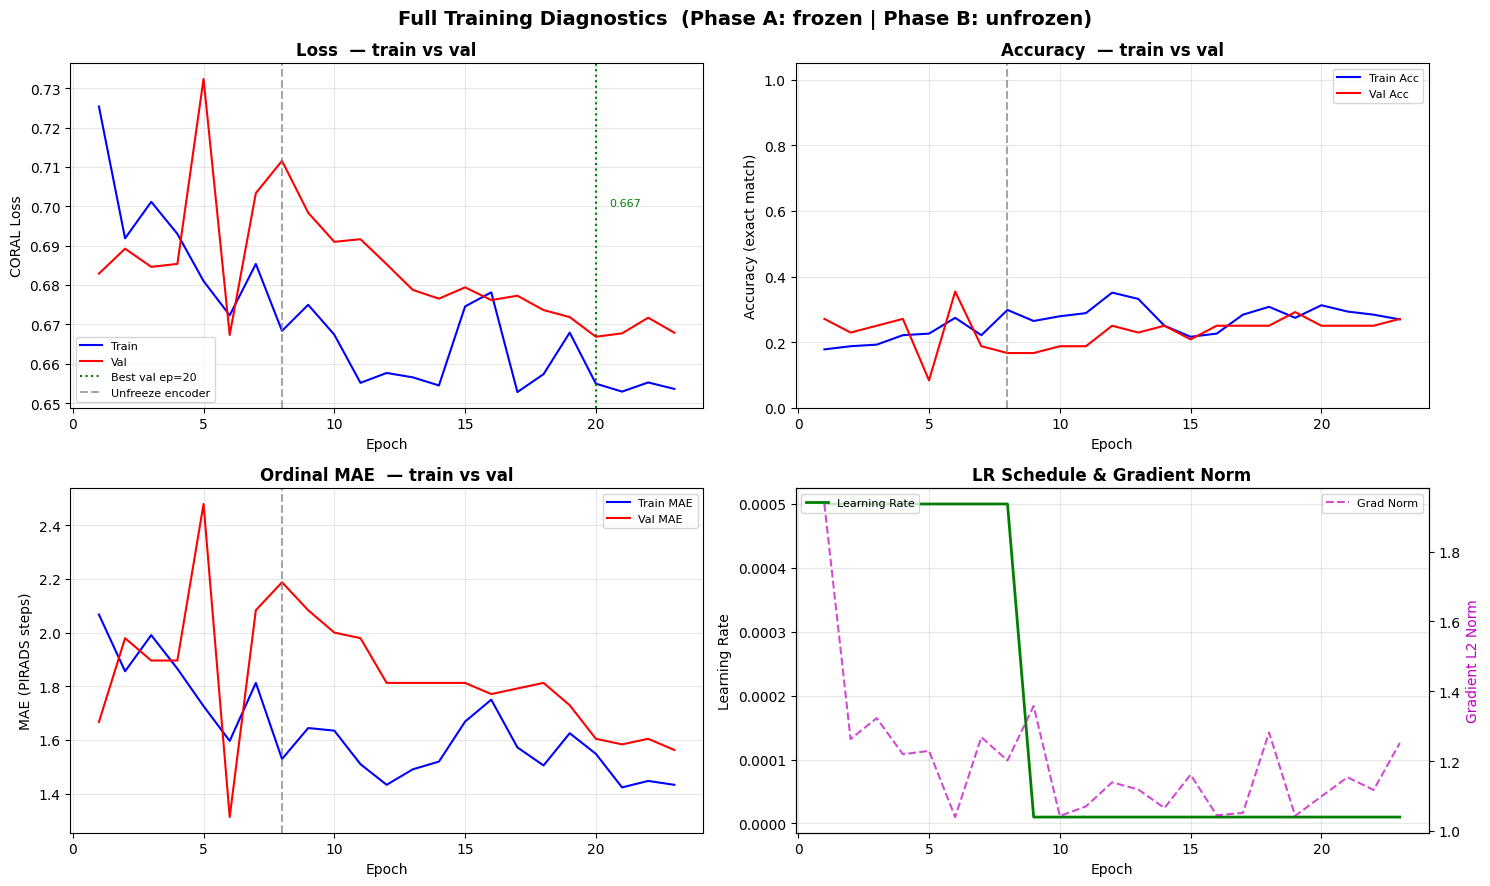

  Overfit gap (val-train loss): max=0.0514  final=0.0143


In [15]:
from src.evaluate import plot_training_curves

# Merge Phase A + Phase B histories
def merge_histories(ha, hb):
    merged = {}
    for key in ha:
        if isinstance(ha[key], list):
            merged[key] = ha[key] + hb.get(key, [])
    return merged

combined = merge_histories(history_a, history_b)

plot_training_curves(
    combined,
    title       = "Full Training Diagnostics  (Phase A: frozen | Phase B: unfrozen)",
    phase_a_len = len(history_a["train_loss"]),
)


## 5. Phase 4 — Test Set Evaluation


  SimCLR + TemporalAgg + CORAL  [T2-only]  —  Test Set
  AUC-ROC          : 0.5867   <- primary metric
  PR-AUC           : 0.6119   <- important w/ class imbalance
  Sensitivity      : 0.6000   (recall, true-positive rate)
  Specificity      : 0.5714   (true-negative rate)
  PPV (Precision)  : 0.6250
  NPV              : 0.5455
  F1 Binary        : 0.6122
  F1 Macro         : 0.1556
  Balanced Acc     : 0.5857
  MCC              : 0.1709   ([-1,1], robust to imbalance)
  QWK              : 0.2579   (ordinal agreement, 0=random)
  Ordinal MAE      : 1.5652  (PIRADS steps avg error)
  Exact Accuracy   : 0.2391
  ECE              : 0.0772   (calibration error, lower=better)
  Per-class AUC    : P1=0.490  P2=0.375  P3=0.445  P4=0.704  P5=0.631
  n samples        : 46


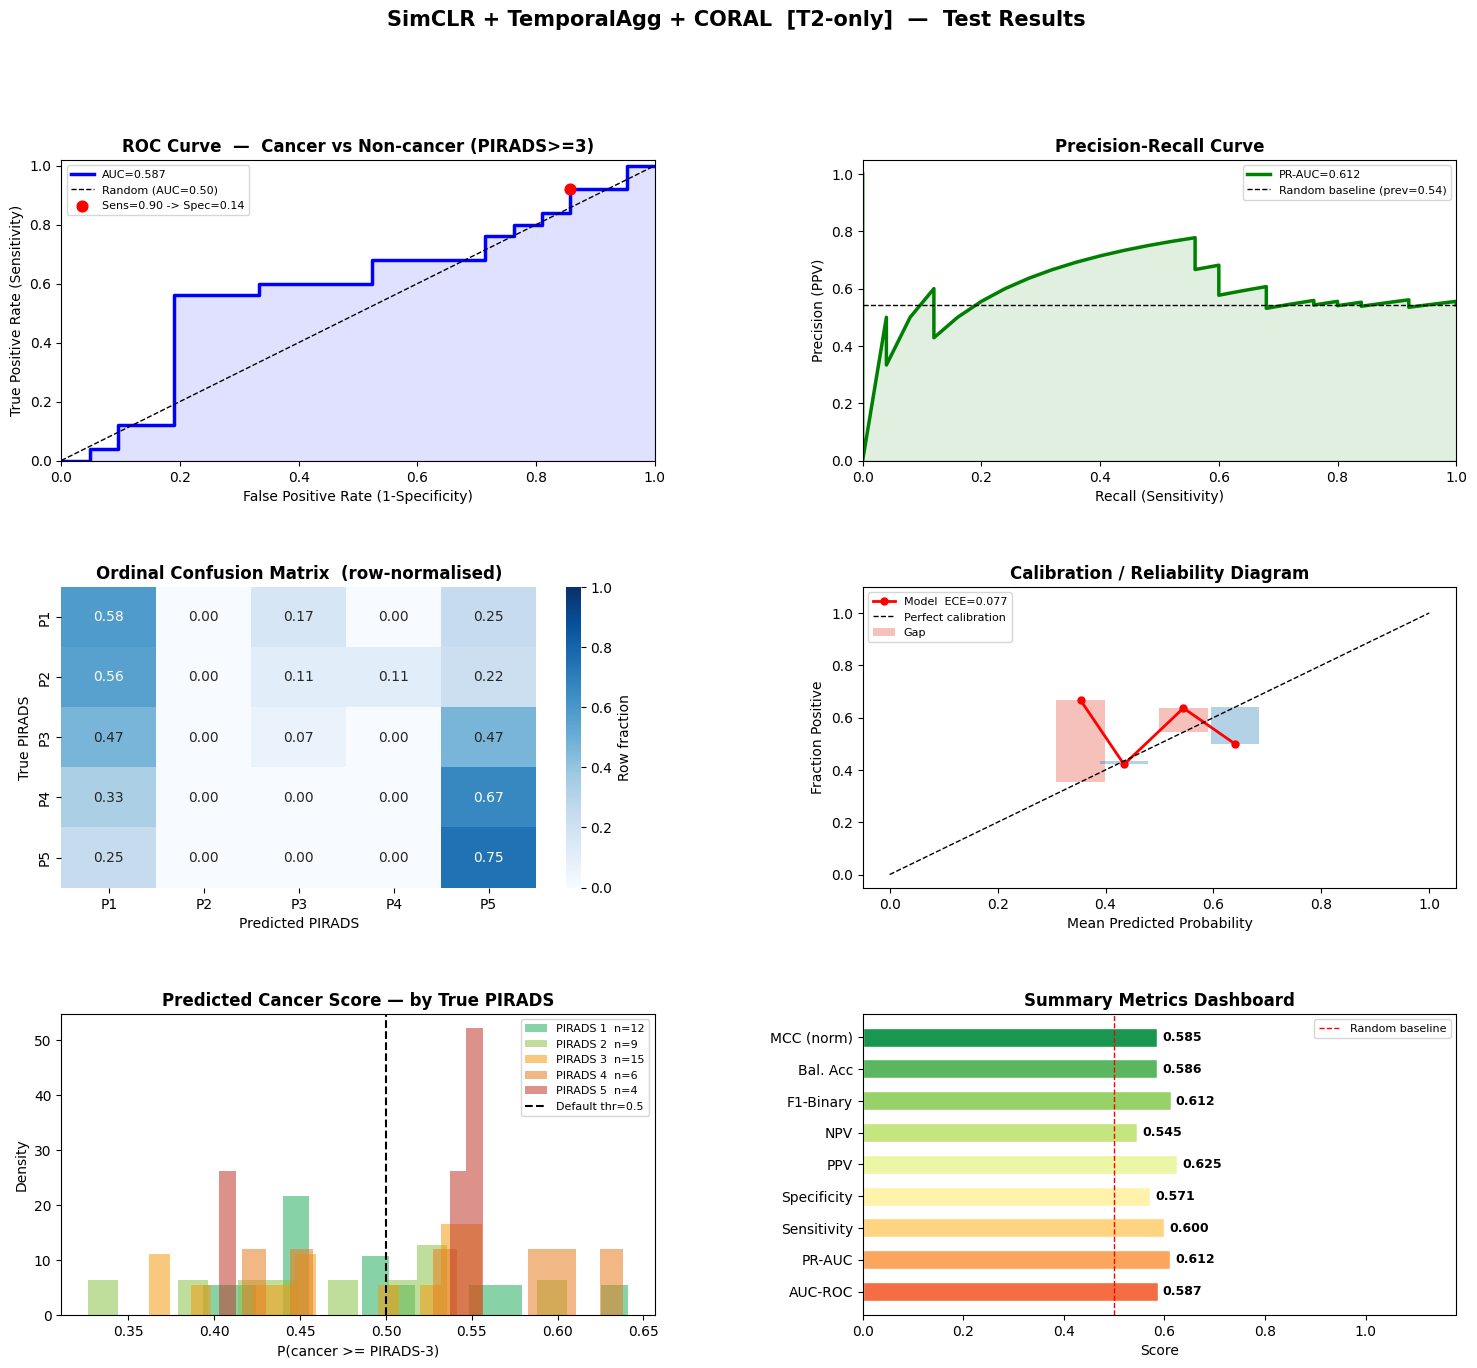

In [16]:
from src.evaluate import evaluate_classifier, print_metrics, plot_results

classifier.load_state_dict(torch.load(str(WEIGHTS_DIR / "classifier_best.pth"), map_location=DEVICE))
classifier.eval()

test_results = evaluate_classifier(classifier, test_loader, DEVICE,
                                   num_classes=5, cancer_threshold=2)
print_metrics(test_results, title="SimCLR + TemporalAgg + CORAL  [T2-only]  —  Test Set")
plot_results(test_results,  title="SimCLR + TemporalAgg + CORAL  [T2-only]  —  Test Results")


## 5b. Extended Evaluation — Threshold Analysis & Per-class ROC

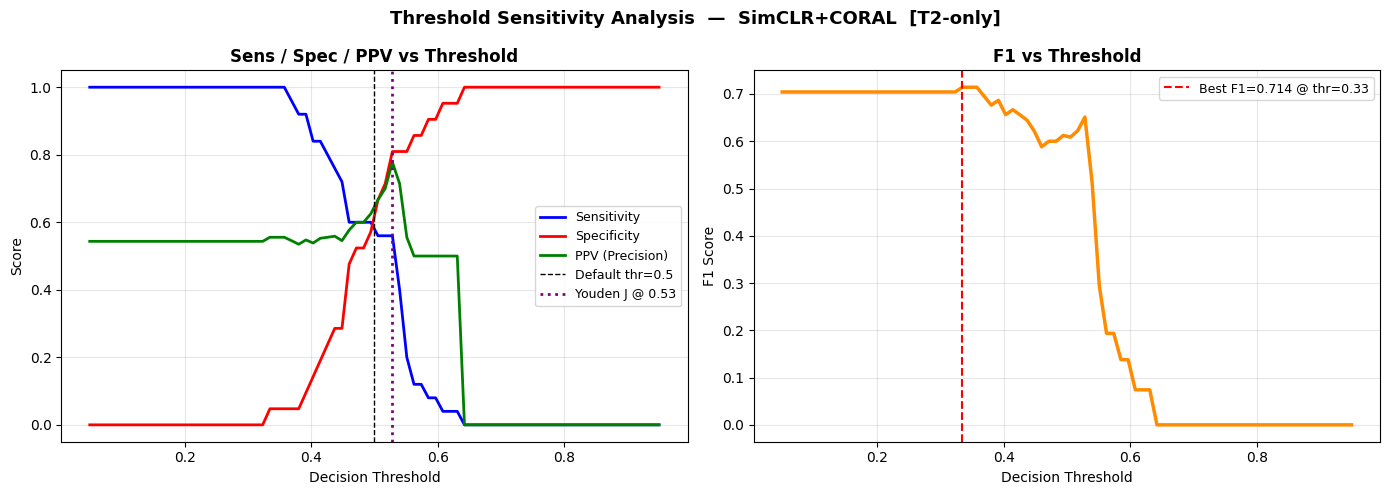

  Youden-optimal threshold: 0.528  (Sens=0.560, Spec=0.810)
  F1-optimal threshold    : 0.335  (F1=0.714)


In [17]:
from src.evaluate import plot_threshold_analysis, plot_per_class_roc

plot_threshold_analysis(
    test_results,
    title="Threshold Sensitivity Analysis  —  SimCLR+CORAL  [T2-only]",
)


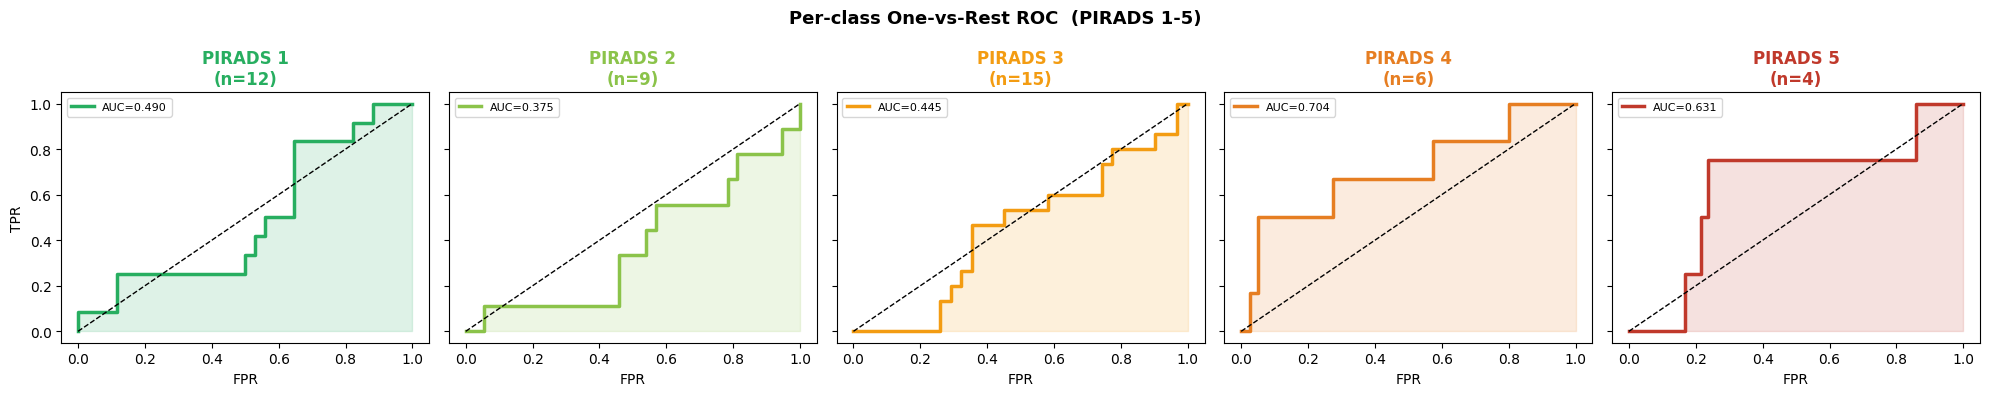

In [18]:
plot_per_class_roc(test_results)
